# Notebook for preprocessing EDGAR8 for use as anthropogenic prior

* select years
* cut domain
* sum sector-specific gridded fluxes together 

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import os
import re


In [50]:
DATA_PATH1 = "/home/pietaril/Documents/data/EDGAR8_CO2/bio_EDGAR/"
DATA_PATH2 = "/home/pietaril/Documents/data/EDGAR8_CO2/IEA_EDGAR/"
OUT_PATH = "/home/pietaril/Documents/data/EDGAR8_CO2/gridded_monthly_flux_sums/"



def get_filenames(dirpaths):
    filenames = []
    for dirpath in dirpaths:
        for subdir in os.listdir(dirpath):
            subdirpath = os.path.join(dirpath, subdir)
            filenames +=  [os.path.join(subdirpath,f) for f in os.listdir(subdirpath) if f.endswith(".nc")]
    return filenames


def extract_year(filename):
    #Extract year from filename
    year = int(re.findall(r'\d{4}', filename)[-1])
    return year

def select_area(aoi, ds):
    # Select the area based on area of interest
    
    area_subset = ds.sel(lon=slice(aoi[0], aoi[1]),
                    lat=slice(aoi[2], aoi[3]))
    return area_subset





def sum_fluxes(aoi, input_files, output_file):
    """
    Sums the 'fluxes' variable across multiple NetCDF files and writes the result to a new NetCDF file.

    Parameters:
    - input_files (list of str): List of paths to input NetCDF files.
    - output_file (str): Path to the output NetCDF file.
    """
 

    # Open all input files
    datasets = [xr.open_dataset(file) for file in input_files]
    

    #pick area
    subsets = [select_area(aoi, ds) for ds in datasets]

    # Compute the sum of fluxes across all datasets

    flux_sum = sum(ds for ds in subsets)

    #rename variables to match CIF standard
    rename_map = {
        "lat": "latitude",
        "lon": "longitude"
    }
    flux_sum = flux_sum.rename(rename_map)
    

    # Save the result to a new NetCDF file
    
    flux_sum.attrs.update({"description": "Sum of gridded EDGAR_2024_GHG CO2 monthly fluxes across all sectors"})#,
                           #"units": datasets[0].attrs["units"]})



    # Write the output dataset to a new NetCDF file
    flux_sum.to_netcdf(output_file, encoding={'time':{'units': "days since 1900-01-01"}})

    # Close all datasets
    for ds in datasets:
        ds.close()

    print(f"Sum of fluxes saved to file {output_file}")

    






In [32]:



aoi = [-15, 40, 34, 73]

fnames = get_filenames([DATA_PATH1, DATA_PATH2])


# create DataFrame with filenames and years to later group by year
df_filenames = pd.DataFrame({'filename': fnames})
df_filenames['year'] = df_filenames['filename'].apply(extract_year)
df_filenames = df_filenames.sort_values('year').reset_index(drop=True)

for year in range(2008, 2024):
    files_1year = df_filenames[df_filenames['year']==year]['filename'].to_list()
    assert len(files_1year)==16
    output_file = f"{OUT_PATH}EDGAR8_CO2_monthly_flux_sums_{year}.nc"
    sum_fluxes(aoi, files_1year, output_file)
    


Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/gridded_monthly_flux_sums/EDGAR8_CO2_monthly_flux_sums_2008.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/gridded_monthly_flux_sums/EDGAR8_CO2_monthly_flux_sums_2009.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/gridded_monthly_flux_sums/EDGAR8_CO2_monthly_flux_sums_2010.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/gridded_monthly_flux_sums/EDGAR8_CO2_monthly_flux_sums_2011.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/gridded_monthly_flux_sums/EDGAR8_CO2_monthly_flux_sums_2012.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/gridded_monthly_flux_sums/EDGAR8_CO2_monthly_flux_sums_2013.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/gridded_monthly_flux_sums/EDGAR8_CO2_monthly_flux_sums_2014.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/gridded

In [38]:
sum_files = os.listdir(OUT_PATH)
print(sum_files[5])
sum_fluxes = xr.open_dataset(OUT_PATH+sum_files[5])
sum_fluxes

EDGAR8_CO2_monthly_flux_sums_2019.nc


<xarray.Dataset>
Dimensions:    (latitude: 390, longitude: 550, time: 12)
Coordinates:
  * latitude   (latitude) float64 34.05 34.15 34.25 34.35 ... 72.75 72.85 72.95
  * longitude  (longitude) float64 -14.95 -14.85 -14.75 ... 39.75 39.85 39.95
  * time       (time) datetime64[ns] 2019-01-15 2019-02-15 ... 2019-12-15
Data variables:
    fluxes     (time, latitude, longitude) float32 ...
Attributes:
    description:  Sum of gridded EDGAR_2024_GHG CO2 monthly fluxes across all...

In [36]:
import netCDF4 as nc
print(sum_files[0])
data_nc = nc.Dataset(OUT_PATH+sum_files[0], 'r')
data_nc.variables

EDGAR8_CO2_monthly_flux_sums_2017.nc


{'latitude': <class 'netCDF4._netCDF4.Variable'>
 float64 latitude(latitude)
     _FillValue: nan
     units: degrees_north
     standard_name: latitude
     long_name: latitude
 unlimited dimensions: 
 current shape = (390,)
 filling on,
 'longitude': <class 'netCDF4._netCDF4.Variable'>
 float64 longitude(longitude)
     _FillValue: nan
     units: degrees_east
     standard_name: longitude
     long_name: longitude
 unlimited dimensions: 
 current shape = (550,)
 filling on,
 'time': <class 'netCDF4._netCDF4.Variable'>
 int64 time(time)
     long_name: time
     standard_name: time
     units: days since 1900-01-01
     calendar: proleptic_gregorian
 unlimited dimensions: 
 current shape = (12,)
 filling on, default _FillValue of -9223372036854775806 used,
 'fluxes': <class 'netCDF4._netCDF4.Variable'>
 float32 fluxes(time, latitude, longitude)
     _FillValue: nan
 unlimited dimensions: 
 current shape = (12, 390, 550)
 filling on}

# Rename variables in the already processed files

In [10]:
def rename_variables_in_netcdf(input_dir, output_dir, rename_map):
    """
    Reads NetCDF files from a directory, renames specified variables, and writes the changes to new files.

    Parameters:
        input_dir (str): Directory containing input NetCDF files.
        output_dir (str): Directory to save the modified NetCDF files.
        rename_map (dict): Mapping of old variable names to new variable names (e.g., {'old_var': 'new_var'}).
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for filename in os.listdir(input_dir):
        if filename.endswith(".nc"):
            input_path = os.path.join(input_dir, filename)
            output_path = os.path.join(output_dir, filename)

            try:
                # Open the NetCDF file
                ds = xr.open_dataset(input_path)

                # Rename variables
                ds = ds.rename(rename_map)

                # Write the modified dataset to a new file
                ds.to_netcdf(output_path)

                print(f"Processed file: {filename}")

            except Exception as e:
                print(f"Error processing file {filename}: {e}")

# Example usage
if __name__ == "__main__":
    # Define input directory, output directory, and rename mapping
    input_directory =  "/home/pietaril/Documents/data/EDGAR8_CO2/gridded_monthly_flux_sums_old/"
    output_directory = "/home/pietaril/Documents/data/EDGAR8_CO2/gridded_monthly_flux_sums/"
    variable_rename_map = {
        "lat": "latitude",
        "lon": "longitude"
    }

    rename_variables_in_netcdf(input_directory, output_directory, variable_rename_map)




Processed file: EDGAR8_CO2_monthly_flux_sums_2017.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2016.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2021.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2011.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2010.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2019.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2015.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2009.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2020.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2022.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2012.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2014.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2018.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2008.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2013.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2023.nc


# Plot the preprocessed fluxes

In [5]:
#from datetime import datetime
data = sum_fluxes["fluxes"]
str(data.time.values[0])[0:7]


'2017-01'

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


def plot_fluxmaps(sum_fluxes, figpath):
    data = sum_fluxes["fluxes"]
    g = data.plot.pcolormesh(x="longitude", y="latitude", col="time", col_wrap=4, robust=True, aspect=1.2,
                     subplot_kws=dict(projection=ccrs.PlateCarree()), cbar_kwargs = dict(label = "anth CO$_2$ prior flux [$kg$ $m^{-2} s^{-1}$]", shrink=0.9 ),

    )


    for i, ax in enumerate(g.axes.flat):
        time = str(data.time.values[i])[0:7]
        ax.set_title(time)
        ax.coastlines()
        ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    plt.draw()
    figname = f"EDGAR8_summed_monthly_CO2_fluxmaps_{time[0:4]}.svg"
    plt.savefig(figpath)
    



In [ ]:

sum_files = os.listdir(OUT_PATH)
for file in sum_files:
    sum_fluxes = xr.open_dataset(OUT_PATH+file)
    plot_fluxmaps(sum_fluxes, "/home/pietaril/Documents/plots/EDGAR8/summed_gridmaps/")
    sum_fluxes.close()


Plot monthly total timeseries

In [77]:

monthly_totals = pd.DataFrame()
fnames = [OUT_PATH+file for file in sum_files]
for fname in fnames:
    year = extract_year(fname)
    ds = xr.open_dataset(fname)
    data = ds["fluxes"]
    vals = data.sum(dim=["latitude", "longitude"]).values
    monthly_totals[year] = vals
    ds.close()

monthly_totals = monthly_totals.sort_index(axis=1)
#monthly_totals = xr.DataArray(monthly_totals)



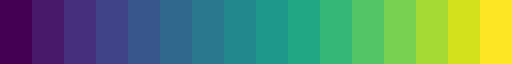

In [89]:
viridis

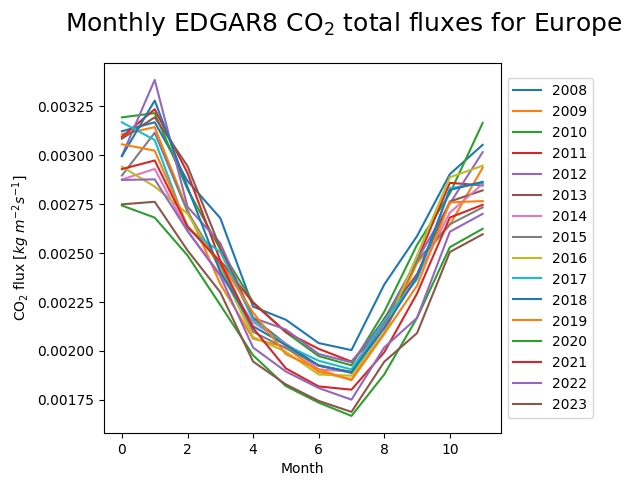

In [92]:

import matplotlib

viridis = matplotlib.colormaps['viridis'].resampled(16)
fig, ax = plt.subplots(layout="constrained")
ax.plot(monthly_totals, label=monthly_totals.columns)
ax.set_xlabel("Month")
ax.set_ylabel("CO$_2$ flux [$kg$ $m^{-2} s^{-1}$]")
#Shrink current axis by 20%
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.suptitle(f"Monthly EDGAR8 CO$_2$ total fluxes for Europe", fontsize=18)
plt.show()




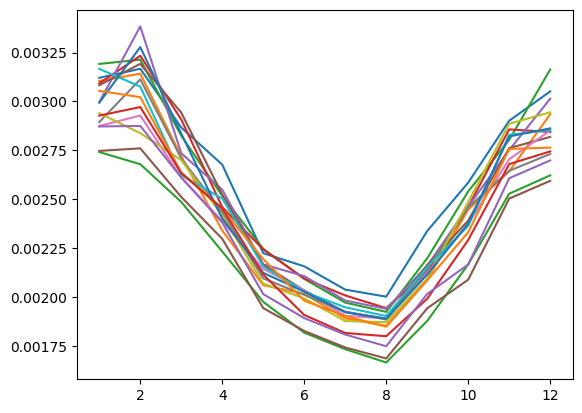

In [47]:
g.axes.flat

In [52]:
datasets[0]

<xarray.Dataset>
Dimensions:  (lat: 1800, lon: 3600, time: 12)
Coordinates:
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.7 ... 179.8 179.8 179.9
  * time     (time) datetime64[ns] 2000-01-15 2000-02-15 ... 2000-12-15
Data variables:
    fluxes   (time, lat, lon) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    description:       Fuel exploitation
    institution:       European Commission, Joint Research Centre
    source:            https://edgar.jrc.ec.europa.eu/dataset_ghg2024
    how_to_cite:       https://edgar.jrc.ec.europa.eu/dataset_ghg2024#howtocite
    copyright_notice:  https://edgar.jrc.ec.europa.eu/dataset_ghg2024#conditions
    contacts:          https://edgar.jrc.ec.europa.eu/dataset_ghg2024#info JR...
    units:             kg m-2 s-1

In [48]:
fluxes_sum

<xarray.Dataset>
Dimensions:  (lat: 1800, lon: 3600, time: 12)
Coordinates:
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.7 ... 179.8 179.8 179.9
  * time     (time) datetime64[ns] 2000-01-15 2000-02-15 ... 2000-12-15
Data variables:
    fluxes   (time, lat, lon) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [30]:
da2 = xr.open_dataarray(files_1year["filename"][1])

# Look at dryrun inputs to infer formatting

* OBS! Xarray seems to automatically display the time as datetime64, but when opening the file with netCDF4 command nc.Dataset(path, 'r'), it displays the actual unit used

In [5]:
TESTPATH = "/home/pietaril/Documents/data/cif_test_inputs/testinput_from_sara/CH4_emisch4_2020_02X02.nc"
ds = xr.open_dataset(TESTPATH)
ds

<xarray.Dataset>
Dimensions:    (time: 12, latitude: 900, longitude: 1800)
Coordinates:
  * time       (time) datetime64[ns] 2020-01-01 2020-02-01 ... 2020-12-01
  * latitude   (latitude) float32 -90.0 -89.8 -89.6 -89.4 ... 89.4 89.6 89.8
  * longitude  (longitude) float32 -180.0 -179.8 -179.6 ... 179.4 179.6 179.8
Data variables:
    emisch4    (time, latitude, longitude) float64 ...
Attributes:
    history:  monthly mean total CH4 emission EDGARv8/GAINS lpx/JSBACH GFED o...
    contact:  anteneh.mengistu@fmi.fi

In [9]:
import netCDF4 as nc
data_nc = nc.Dataset(TESTPATH, 'r')
data_nc.variables

{'time': <class 'netCDF4._netCDF4.Variable'>
 float32 time(time)
     units: days since 1900-01-01
     long_name: output_time
 unlimited dimensions: 
 current shape = (12,)
 filling on, default _FillValue of 9.969209968386869e+36 used,
 'latitude': <class 'netCDF4._netCDF4.Variable'>
 float32 latitude(latitude)
     units: degrees_north
     long_name: latitude
 unlimited dimensions: 
 current shape = (900,)
 filling on, default _FillValue of 9.969209968386869e+36 used,
 'longitude': <class 'netCDF4._netCDF4.Variable'>
 float32 longitude(longitude)
     units: degrees_east
     long_name: longitude
 unlimited dimensions: 
 current shape = (1800,)
 filling on, default _FillValue of 9.969209968386869e+36 used,
 'emisch4': <class 'netCDF4._netCDF4.Variable'>
 float64 emisch4(time, latitude, longitude)
     units: kg(CH4)/m2/hr
 unlimited dimensions: 
 current shape = (12, 900, 1800)
 filling on, default _FillValue of 9.969209968386869e+36 used}